<a href="https://colab.research.google.com/github/JoshM435/ACTCW2/blob/main/py/Q3_folder/ACT_CW2_Q3_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook will cover Q3, i will exploring Research question 1, How does Data Augmentation affect the performance of a Neural Network?

Data Augmentaion in general can improve the performance of a Neural Network, but can also degrade functionality if done incorrectly, because you are artificially increasing the diversity of the training set by applying various transformations to the images and relevant annotations.

Data Augmentation can cause:

1. Generalization
  * Neural Networks are often liable to overfit towards training data, where potentially they kearn patterns specific to the training set as opposed to general features.
  * Where Data Augmentation can introduce variety within a Dataset (rotations, scaling, cropping, colour variety), which can help the model to learn more general features, which can lead to an improvement in the ability to generalize unseen data/images.

2. Increased Dataset Size
  * Smaller datasets sometimes do not provide enough samples to learn the relevant features when training.
  * Augmentation of the dataset can be used to effectively increase the size of the training data, the unique variations that can be made will provide more unique samples that the Neural Network can learn from.
3. Variations in data
  * Specifically for this dataset it is important to note that Aircraft can appear in a plethra of orientations, lighting and sizes(scale).
  * With Data Augmentation you can simulate these variations during training:
    * Flipping can simulate variety in data.
    * Scaling/cropping can help the model to detect objects at different scales and positions.
    * Brightness and Contrast application can mimic changes in lighting.
4. Overfitting
  * Overfitting happens when the network memorizes the training data instead of learning meaningful patterns.
  * Augmentation can help to create new examples for each training epoch, making it harder for the model to memorize specific data points and encouraging it to learn patterns.
5. Challenges
  * Augmentations such as cropping or rotation must also update the blunding boxes to match the transformed images. If the boxes aren't adjusted correctly the performance can be degraded.
  * Over augmentation can lead to unrealistic data examples, which could cause a model to perform poorly on real-world data.

Potential Augmentations for Faster R-CNN:
  
  Geometric Transforms -

    * Random flipping
    * Random Rotation
    * Scaling
  
  Photometric Transforms -

    * Brightness, contrast, saturation.
    * Colour Jitter.

  Bounding-Box augmentations -

    * Random Cropping.
    * Random Cutouts.

Overall Data Augmentation Often leads to Performance Improvements when done correctly. It can lead to higher accuracy, reduced overfitting and better handling of variety in object appearance.


Python Dependencies for this Notebook:

In [ ]:
import kagglehub
import pandas as pd
import os
import tensorflow
import matplotlib.pyplot as plt
import ast
import torch
import torchvision.transforms as T
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.transforms import functional as F
from PIL import Image, ImageDraw, ImageFont
import numpy as np
import random
from torchvision.ops import box_iou
from torchvision.models.detection.faster_rcnn import FasterRCNN_ResNet50_FPN_Weights

Below will consisy of the adapted code with the Data augmentations applied through a Augmentation pipeline.

The majority of the functionality is retained from Notebook_Q2.

In [ ]:
# Download the dataset
path = kagglehub.dataset_download("airbusgeo/airbus-aircrafts-sample-dataset")
print("Path to dataset files:", path)

# Explore the annotations
annotations_path = os.path.join(path, "annotations.csv")
annotations = pd.read_csv(annotations_path)
print(annotations.head())

# Verify images
images_path = os.path.join(path, "images")
print("Number of images:", len(os.listdir(images_path)))


Path to dataset files: /root/.cache/kagglehub/datasets/airbusgeo/airbus-aircrafts-sample-dataset/versions/3
   id                                  image_id  \
0   1  4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg   
1   2  4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg   
2   3  4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg   
3   4  4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg   
4   5  4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg   

                                            geometry     class  
0  [(135, 522), (245, 522), (245, 600), (135, 600...  Airplane  
1  [(1025, 284), (1125, 284), (1125, 384), (1025,...  Airplane  
2  [(1058, 1503), (1130, 1503), (1130, 1568), (10...  Airplane  
3  [(813, 1518), (885, 1518), (885, 1604), (813, ...  Airplane  
4  [(594, 938), (657, 938), (657, 1012), (594, 10...  Airplane  
Number of images: 103


In [ ]:
# Function to parse the geometry field and extract a rectangular bounding box
def polygon_to_bbox(polygon_str):
    """
    Converts a polygon (as a string of tuples) to a bounding box (x_min, y_min, x_max, y_max).
    """
    # Parse the string to a list of tuples
    polygon = ast.literal_eval(polygon_str)
    # Extract x and y coordinates separately
    x_coords = [point[0] for point in polygon]
    y_coords = [point[1] for point in polygon]
    # Determine the bounding box
    x_min, x_max = min(x_coords), max(x_coords)
    y_min, y_max = min(y_coords), max(y_coords)
    return x_min, y_min, x_max, y_max

# Apply the function to the annotations dataframe
annotations['bbox'] = annotations['geometry'].apply(polygon_to_bbox)

# Display the dataframe with the new bounding box column
annotations.head()

,id,image_id,geometry,class,bbox
0,1,4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg,"[(135, 522), (245, 522), (245, 600), (135, 600...",Airplane,"(135, 522, 245, 600)"
1,2,4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg,"[(1025, 284), (1125, 284), (1125, 384), (1025,...",Airplane,"(1025, 284, 1125, 384)"
2,3,4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg,"[(1058, 1503), (1130, 1503), (1130, 1568), (10...",Airplane,"(1058, 1503, 1130, 1568)"
3,4,4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg,"[(813, 1518), (885, 1518), (885, 1604), (813, ...",Airplane,"(813, 1518, 885, 1604)"
4,5,4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg,"[(594, 938), (657, 938), (657, 1012), (594, 10...",Airplane,"(594, 938, 657, 1012)"


These three functions are used to augment the data for the dataset, with three options, consisting of horizontally flipping an image, vertically flipping an image and rotating an image by 90 degrees, whilst also rotating/flipping their relevant bounding boxes.

I took this approach to try and provide the model with more variations in orientation of planes.

In [ ]:
def horizontal_flip(image, boxes):
    """
    Horizontally flips the image and adjusts bounding boxes.
    """
    image = F.hflip(image)  # Flip the image
    w, _ = image.size  # Image width
    flipped_boxes = boxes.clone()
    flipped_boxes[:, [0, 2]] = w - boxes[:, [2, 0]]  # Adjust x_min and x_max
    return image, flipped_boxes

def vertical_flip(image, boxes):
    """
    Vertically flips the image and adjusts bounding boxes.
    """
    image = F.vflip(image)  # Flip the image
    _, h = image.size  # Image height
    flipped_boxes = boxes.clone()
    flipped_boxes[:, [1, 3]] = h - boxes[:, [3, 1]]  # Adjust y_min and y_max
    return image, flipped_boxes

def rotate_90(image, boxes):
    """
    Rotates the image by 90 degrees and adjusts bounding boxes.
    """
    image = F.rotate(image, angle=90)  # Rotate image
    w, h = image.size
    rotated_boxes = boxes.clone()
    rotated_boxes[:, [0, 1, 2, 3]] = boxes[:, [1, 0, 3, 2]]  # Swap x and y coordinates
    rotated_boxes[:, [0, 2]] = h - rotated_boxes[:, [2, 0]]  # Adjust x coordinates
    return image, rotated_boxes


This class is the pipeline that gets called when going through the training process. It allows for random execution of the potential augmentations, based of the random function.

In [ ]:
class AugmentationPipeline:
    def __init__(self, p_flip=0.5, p_rotate=0.3):
        self.p_flip = p_flip
        self.p_rotate = p_rotate

    def __call__(self, image, boxes):
        # Random horizontal flip
        if random.random() < self.p_flip:
            image, boxes = horizontal_flip(image, boxes)

        # Random vertical flip
        if random.random() < self.p_flip:
            image, boxes = vertical_flip(image, boxes)

        # Random 90-degree rotation
        if random.random() < self.p_rotate:
            image, boxes = rotate_90(image, boxes)

        return image, boxes


Adjusted AircraftDataset to allow for the use of augmentation.

In [ ]:
# Define the custom PyTorch Dataset class
class AircraftDataset(Dataset):
    def __init__(self, annotations_df, images_dir, transform=None,augmentations=None):
        """
        Args:
            annotations_df (pd.DataFrame): DataFrame containing image_id, bbox, and class.
            images_dir (str): Path to the directory containing images.
            transform (callable, optional): Optional transform to apply to images.
        """
        self.annotations_df = annotations_df
        self.images_dir = images_dir
        self.transform = transform
        self.augmentations = augmentations
        # Map class names to numeric labels
        self.class_to_label = {cls: idx + 1 for idx, cls in enumerate(annotations_df['class'].unique())}
        self.label_to_class = {idx + 1: cls for idx, cls in enumerate(annotations_df['class'].unique())}

    def __len__(self):
        return len(self.annotations_df['image_id'].unique())

    def __getitem__(self, idx):
        # Get the image ID and filter annotations for this image
        image_id = self.annotations_df['image_id'].unique()[idx]
        image_path = os.path.join(self.images_dir, image_id)
        annotations = self.annotations_df[self.annotations_df['image_id'] == image_id]

        # Load the image
        image = Image.open(image_path).convert("RGB")

        # Extract bounding boxes and labels
        boxes = torch.tensor([list(bbox) for bbox in annotations['bbox']], dtype=torch.float32)
        labels = torch.tensor([self.class_to_label[cls] for cls in annotations['class']], dtype=torch.int64)

        if self.augmentations:
          image, boxes = self.augmentations(image, boxes)

        # Create the target dictionary
        target = {"boxes": boxes, "labels": labels}

        # Apply transformations if specified
        if self.transform:
            image = self.transform(image)

        return image, target

# Define the image directory path
images_dir = os.path.join(path, 'images')

# Define simple transforms (resize and normalize images)
transform = T.Compose([
    T.ToTensor(),# Convert image to tensor
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229, 0.224, 0.225])
])

# Instantiate the dataset
dataset = AircraftDataset(annotations, images_dir, transform=transform)

# Display a sample for verification
sample_image, sample_target = dataset[0]
sample_image.shape, sample_target

(torch.Size([3, 2560, 2560]),
 {'boxes': tensor([[ 135.,  522.,  245.,  600.],
          [1025.,  284., 1125.,  384.],
          [1058., 1503., 1130., 1568.],
          [ 813., 1518.,  885., 1604.],
          [ 594.,  938.,  657., 1012.],
          [ 451.,  725.,  524.,  798.],
          [1543., 1437., 1614., 1497.],
          [1485., 1370., 1561., 1437.],
          [1968., 1624., 2053., 1687.],
          [1659., 1674., 1733., 1746.],
          [1865., 2091., 1951., 2165.],
          [2052., 1772., 2135., 1834.],
          [2146., 2031., 2225., 2102.],
          [1006., 2345., 1088., 2412.],
          [1931., 2163., 2009., 2247.],
          [1231., 1532., 1295., 1607.],
          [ 740., 1268.,  804., 1356.],
          [ 645., 1399.,  730., 1458.]]),
  'labels': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])})

Call Faster R-CNN model.

In [ ]:
# Model Initialization
def get_model(num_classes):
    # Load a Faster R-CNN model
    model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT) #weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT
    # Update the classifier head for the number of classes (including background)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)
    return model

Adjusted train dataset to allow for Augmentation.

In [ ]:
augmentations = AugmentationPipeline(p_flip=0.5, p_rotate=0.3)

train_dataset = AircraftDataset(
    annotations_df=annotations,
    images_dir=images_dir,
    transform=transform,  # Normalization and tensor conversion
    augmentations=augmentations
)
train_loader= DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))


After training it is clear that the data augmentation process has led to inefficiencies in the training process, leading to

Epoch 1/25, Loss: 45.9675
Epoch 2/25, Loss: 30.3943
Epoch 3/25, Loss: 26.8532
Epoch 4/25, Loss: 27.0832
Epoch 5/25, Loss: 24.1363
Epoch 6/25, Loss: 24.0189
Epoch 7/25, Loss: 25.8632
Epoch 8/25, Loss: 22.4156
Epoch 9/25, Loss: 23.0810
Epoch 10/25, Loss: 23.5951
Epoch 11/25, Loss: 23.6727
Epoch 12/25, Loss: 24.3327
Epoch 13/25, Loss: 22.1562
Epoch 14/25, Loss: 22.6134
Epoch 15/25, Loss: 21.8491
Epoch 16/25, Loss: 23.1829
Epoch 17/25, Loss: 22.4146
Epoch 18/25, Loss: 21.7169
Epoch 19/25, Loss: 21.0143
Epoch 20/25, Loss: 23.8924
Epoch 21/25, Loss: 21.7173
Epoch 22/25, Loss: 19.7006
Epoch 23/25, Loss: 20.2681
Epoch 24/25, Loss: 21.9653
Epoch 25/25, Loss: 21.3829


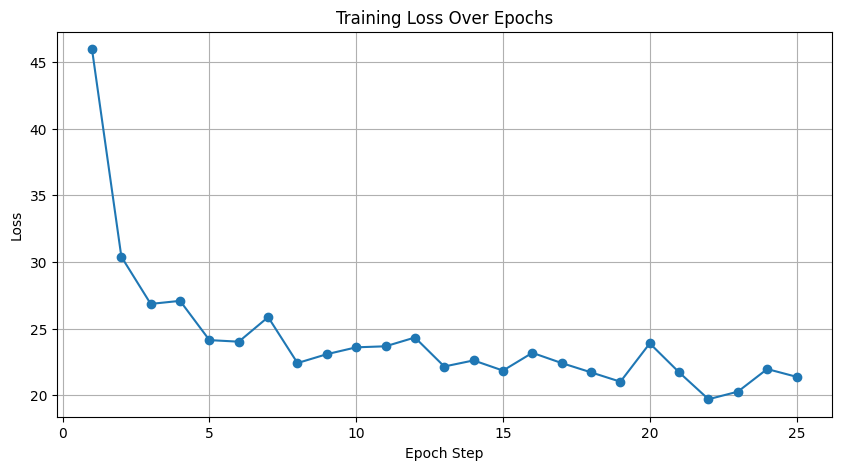

In [ ]:
# Training Loop
def train_model(model, data_loader, optimizer, num_epochs, device):
    model.to(device)
    model.train()

    loss_history = []
    for epoch in range(num_epochs):
        epoch_loss = 0
        for images, targets in data_loader:
            # Move data to the appropriate device
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            # Zero gradients
            optimizer.zero_grad()

            # Forward pass and loss computation
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

            # Backward pass and optimisation
            losses.backward()
            optimizer.step()

            epoch_loss += losses.item()
        loss_history.append(epoch_loss)
        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {epoch_loss:.4f}")
    plt.figure(figsize=(10,5))
    plt.plot(range(1, num_epochs + 1), loss_history, marker='o')
    plt.xlabel('Epoch Step')
    plt.ylabel('Loss')
    plt.title('Training Loss Over Epochs')
    plt.grid()
    plt.show()

# Data Preparation
# annotations_df is the preprocessed DataFrame and images_dir is the folder path
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor()
])

# Create Dataset and DataLoader


# Model, Optimiser, and Device Setup
num_classes = len(train_dataset.class_to_label) + 1  # +1 for background class
model = get_model(num_classes)
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.8, weight_decay=0.0005)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# Train the Model
num_epochs = 25

train_model(model, train_loader, optimizer, num_epochs, device)


function to test model's functionality. Same as Q2.

In [ ]:
# Test Function
def test_model(model, dataset, device, threshold=0.5):
    model.to(device)
    model.eval()

    # Get a sample image and its target
    image, _ = dataset[random.randint(0,102)]  # Modify index to test different images
    image_tensor = image.to(device).unsqueeze(0)  # Add batch dimension

    # Make predictions
    with torch.no_grad():
        predictions = model(image_tensor)

    # Filter predictions by score threshold
    scores = predictions[0]['scores'].cpu().numpy()
    boxes = predictions[0]['boxes'].cpu().numpy()
    labels = predictions[0]['labels'].cpu().numpy()

    filtered_indices = np.where(scores >= threshold)[0]
    filtered_boxes = boxes[filtered_indices]
    filtered_labels = labels[filtered_indices]
    filtered_scores = scores[filtered_indices]

    # Draw predictions on the image
    image = F.to_pil_image(image.cpu())
    draw = ImageDraw.Draw(image)

    Font_Size= 40
    font= ImageFont.load_default(Font_Size)


    for box, label, score in zip(filtered_boxes, filtered_labels, filtered_scores):
        draw.rectangle(box.tolist(), outline="red", width=3)
        text = f"{dataset.label_to_class[label]}: {score:.2f}"
        draw.text((box[0]-40, box[1] - Font_Size), text, fill="red", font=font )

    return image

Function to use model to predict on unseen images. Same as Q2

In [ ]:
def predict_on_unseen_images(model, dataset, device, output_dir, threshold=0.5):
    model.to(device)
    model.eval()
    os.makedirs(output_dir, exist_ok=True)

    for image, image_name in dataset:
        image_tensor = image.to(device).unsqueeze(0)  # Add batch dimension

        # Make predictions
        with torch.no_grad():
            predictions = model(image_tensor)

        # Filter predictions by score threshold
        scores = predictions[0]['scores'].cpu().numpy()
        boxes = predictions[0]['boxes'].cpu().numpy()
        labels = predictions[0]['labels'].cpu().numpy()

        filtered_indices = np.where(scores >= threshold)[0]
        filtered_boxes = boxes[filtered_indices]
        filtered_labels = labels[filtered_indices]
        filtered_scores = scores[filtered_indices]

        # Draw predictions on the image
        image = F.to_pil_image(image.cpu())
        draw = ImageDraw.Draw(image)

        # Load a larger font
        font_size = 40

        font = ImageFont.load_default(font_size)


        for box, label, score in zip(filtered_boxes, filtered_labels, filtered_scores):
            draw.rectangle(box.tolist(), outline="red", width=3)
            text = f"Label {label}: {score:.2f}"
            text_position = (box[0], box[1] - font_size if box[1] - font_size > 0 else box[1] + 5)
            draw.text(text_position, text, fill="red", font=font)

        # Save the annotated image
        output_path = os.path.join(output_dir, image_name)
        image.save(output_path)
        print(f"Processed and saved: {output_path}")

Creation of Unlabelled Dataseet for trained model to predict with. Same as Q2.

In [ ]:
class UnlabelledImageDataset(Dataset):
    def __init__(self, images_dir, transform=None):
        """
        Args:
            images_dir (str): Path to the directory containing images.
            transform (callable, optional): Optional transform to apply to images.
        """
        self.images_dir = images_dir
        self.image_files = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_path = os.path.join(self.images_dir, self.image_files[idx])
        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, self.image_files[idx]

As expected with a negatively impacted training process the models confidence scores with the training set is reduced. And some planes may not be detected with high enough confidence.

Even with the high loss after the training process the model is still functional despite being less effective. This adaptation for data augmentation has proved to be not very effective when working with this model.

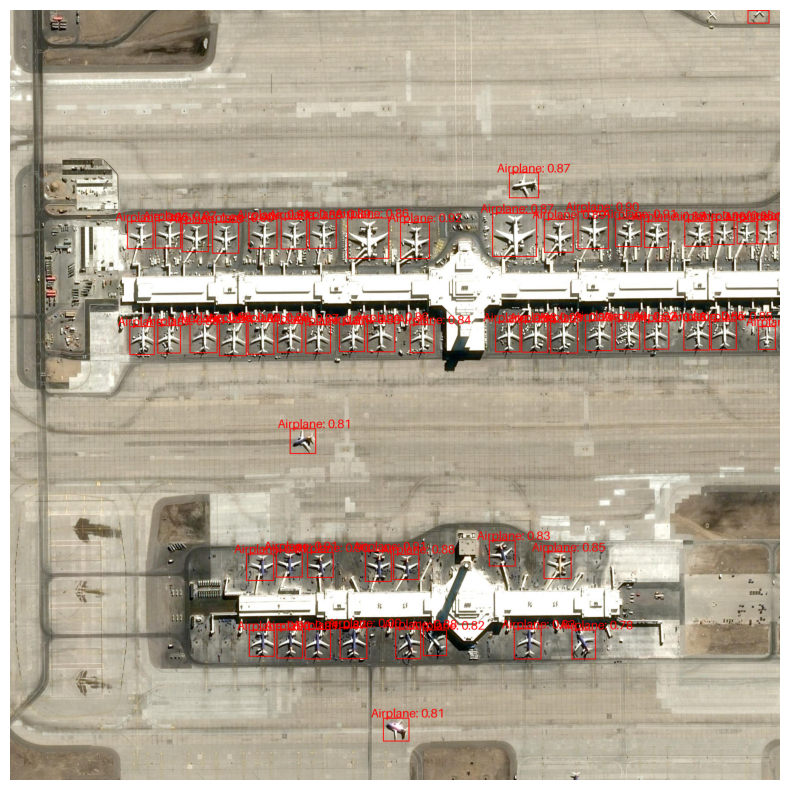

In [ ]:
output_image = test_model(model, train_dataset, device)
plt.figure(figsize=(10, 10))
plt.imshow(output_image)
plt.axis('off')
plt.show()

creation of new directory to store extra images with their plotted predictions. Same as Q2.


In [ ]:
extras_dir = os.path.join(os.path.dirname(images_dir), 'extras')
extras_dataset = UnlabelledImageDataset(extras_dir, transform=transform)

output_dir = os.path.join(os.path.dirname(images_dir), 'predictions')
predict_on_unseen_images(model, extras_dataset, device, output_dir)

Processed and saved: /root/.cache/kagglehub/datasets/airbusgeo/airbus-aircrafts-sample-dataset/versions/3/predictions/65825eef-f8a1-41b3-ac87-4a0a7d482a0e.jpg
Processed and saved: /root/.cache/kagglehub/datasets/airbusgeo/airbus-aircrafts-sample-dataset/versions/3/predictions/08a8132a-a6c7-4cab-adee-7e2976fd2822.jpg
Processed and saved: /root/.cache/kagglehub/datasets/airbusgeo/airbus-aircrafts-sample-dataset/versions/3/predictions/22bc9d20-02c4-4554-8fed-2c127d54b5ed.jpg
Processed and saved: /root/.cache/kagglehub/datasets/airbusgeo/airbus-aircrafts-sample-dataset/versions/3/predictions/defbf838-828b-4427-9bb7-9af33563ea9c.jpg
Processed and saved: /root/.cache/kagglehub/datasets/airbusgeo/airbus-aircrafts-sample-dataset/versions/3/predictions/55aa185a-01c8-4668-ae87-1f1d67d15a08.jpg
Processed and saved: /root/.cache/kagglehub/datasets/airbusgeo/airbus-aircrafts-sample-dataset/versions/3/predictions/022f91f0-1434-401f-a11b-e315b7068100.jpg


same process of checking file creation as Q2.

In [ ]:
files = os.listdir(path)
print("Files in dataset:", files)
extras_predictions = os.listdir(output_dir)
print("Files in predictions:", extras_predictions)


Files in dataset: ['extras', 'images', 'README.md', 'LICENSE.txt', 'predictions', 'annotations.csv']
Files in predictions: ['65825eef-f8a1-41b3-ac87-4a0a7d482a0e.jpg', '08a8132a-a6c7-4cab-adee-7e2976fd2822.jpg', '22bc9d20-02c4-4554-8fed-2c127d54b5ed.jpg', 'defbf838-828b-4427-9bb7-9af33563ea9c.jpg', '55aa185a-01c8-4668-ae87-1f1d67d15a08.jpg', '022f91f0-1434-401f-a11b-e315b7068100.jpg']


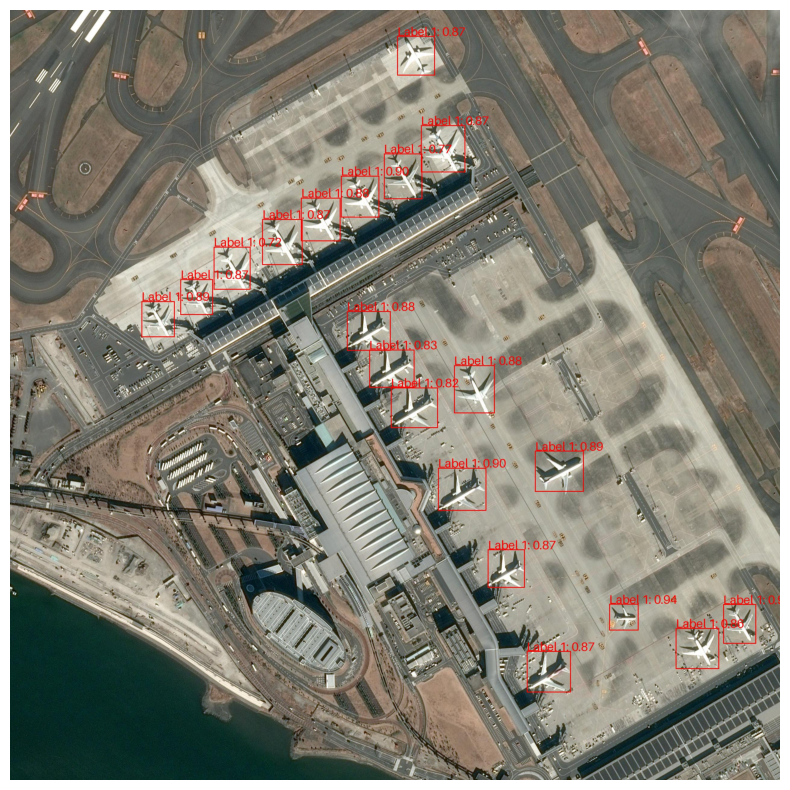

In [ ]:
extras_P = os.path.join(output_dir, extras_predictions[random.randint(0,5)])
extras_Random = Image.open(extras_P).convert("RGB")

plt.figure(figsize=(10, 10))
plt.imshow(extras_Random)
plt.axis('off')
plt.show()

Despite having the training process be negatively impacted from the augmentation process, the model was still able to correctly identify almost all of the planes from an unseen dataset, however with relatively low confidence rates.

In [ ]:
def evaluate_model(model, test_loader, device, iou_threshold=0.5):
    model.to(device)
    model.eval()

    total_true_positives = 0
    total_predictions = 0
    total_ground_truths = 0

    for images, targets in test_loader:
        images = [img.to(device) for img in images]

        with torch.no_grad():
            predictions = model(images)

        for i, prediction in enumerate(predictions):
            pred_boxes = prediction['boxes'].cpu()
            pred_labels = prediction['labels'].cpu()
            pred_scores = prediction['scores'].cpu()

            gt_boxes = targets[i]['boxes']
            gt_labels = targets[i]['labels']

            # Filter predictions by confidence threshold
            filtered_indices = pred_scores > 0.5
            pred_boxes = pred_boxes[filtered_indices]
            pred_labels = pred_labels[filtered_indices]

            # Count total ground truths and predictions
            total_ground_truths += len(gt_boxes)
            total_predictions += len(pred_boxes)

            # Compute IoU and count true positives
            if len(pred_boxes) > 0 and len(gt_boxes) > 0:
                ious = box_iou(pred_boxes, gt_boxes)
                true_positives = (ious.max(dim=1)[0] > iou_threshold).sum().item()
                total_true_positives += true_positives

    # Compute metrics
    precision = total_true_positives / total_predictions if total_predictions > 0 else 0
    recall = total_true_positives / total_ground_truths if total_ground_truths > 0 else 0

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    return precision, recall

evaluate_model(model, train_loader, device)

Precision: 0.6818
Recall: 0.6242


(0.6817602040816326, 0.6242335766423358)

Overall, Data Augmentation is shown to be a tool for improving a Neural Network's performance as well as efficiency, However when used in the manner of image flipping/rotating for my model it proved to be a negative influence on the loss during training.

Where the dataset i used was consisting of 103 images of airports the augmentation proved to be ineffective at amplifying the training process.

As shown, the potential downsides to Data Augmentation can come through increased training time as you may have more images/data to train with, as well as the potential to skew the training process and render the model less effective.

However the potential use cases of data augmentation for smaller sized datasets makes it an excellent technique for model improving and effectiveness.

My Decision for attempting Data Augmentation was to attempt to improve the robustness of the model, whilst also potentially improving the model's funtctionality as a whole, through artificially increasing the diversity of the training data.

The code within this notebook has been adapted from Kaggle and ChatGPT.